# Lab11 - 112078502 楊婷婷
Requirement:

* Try some the input transfromation mentioned above (e.g. shuffle, batch, repeat, map(random_crop, random_flip_left_right, ...)) but without optimization terms (e.g. prefetch, cache, num_parallel_calls)
    * Compare the performance and time consumption to the Naive one.
    * Note that it's important to take some examples and plot the image like block [84] to make sure theat the map function does as you desired
* Re-train your model with optimized terms, comparing the performance and time consumption
* Training both models above for at least 3 epochs.
* Briefly summarize what you did and explain the performance results (accuracy and time consuming).
    * It's fine if you get worse performace after applying input transfromation, or get longer time consumption after applying data pipeline optimization. Just try to analyze the result and propose your assumption, e.g.
        * Is it possible that the more difficult training data after input transfromation may need more epochs to train to get better performance?
        * Which step is the bottleneck on your device? Why? Any other steps cost more time than your expect?

In [22]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
from tensorflow.keras import utils, datasets, layers, models
from tensorflow.keras.applications.vgg16 import VGG16
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
# import IPython.display as displyay
# from IPython.display import display
from IPython.display import display, Image
import matplotlib.pyplot as plt
import pathlib
import random
import numpy as np
import matplotlib as mpl
import time

import csv
import pandas as pd
import math
from tqdm import tqdm

import itertools
from collections import defaultdict

import urllib.request
if not os.path.exists("lab11_1_lib.py"):
    urllib.request.urlretrieve("https://nthu-datalab.github.io/ml/labs/11-1_CNN/lab11_1_lib.py", "lab11_1_lib.py")

from lab11_1_lib import draw_timeline

In [24]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)


1 Physical GPUs, 1 Logical GPUs


## Load data and check

classes:
oregon_wildlife/bald_eagle
oregon_wildlife/black_bear
oregon_wildlife/cougar
oregon_wildlife/deer
oregon_wildlife/nutria
oregon_wildlife/raccoon
oregon_wildlife/raven
oregon_wildlife/red_fox
oregon_wildlife/sea_lions
oregon_wildlife/virginia_opossum

total img num: 7168


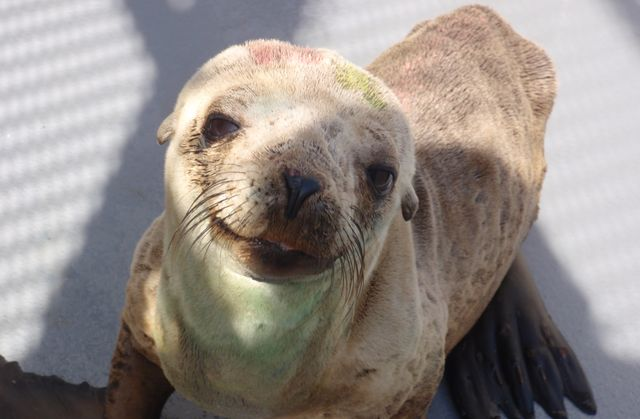

sea_lions


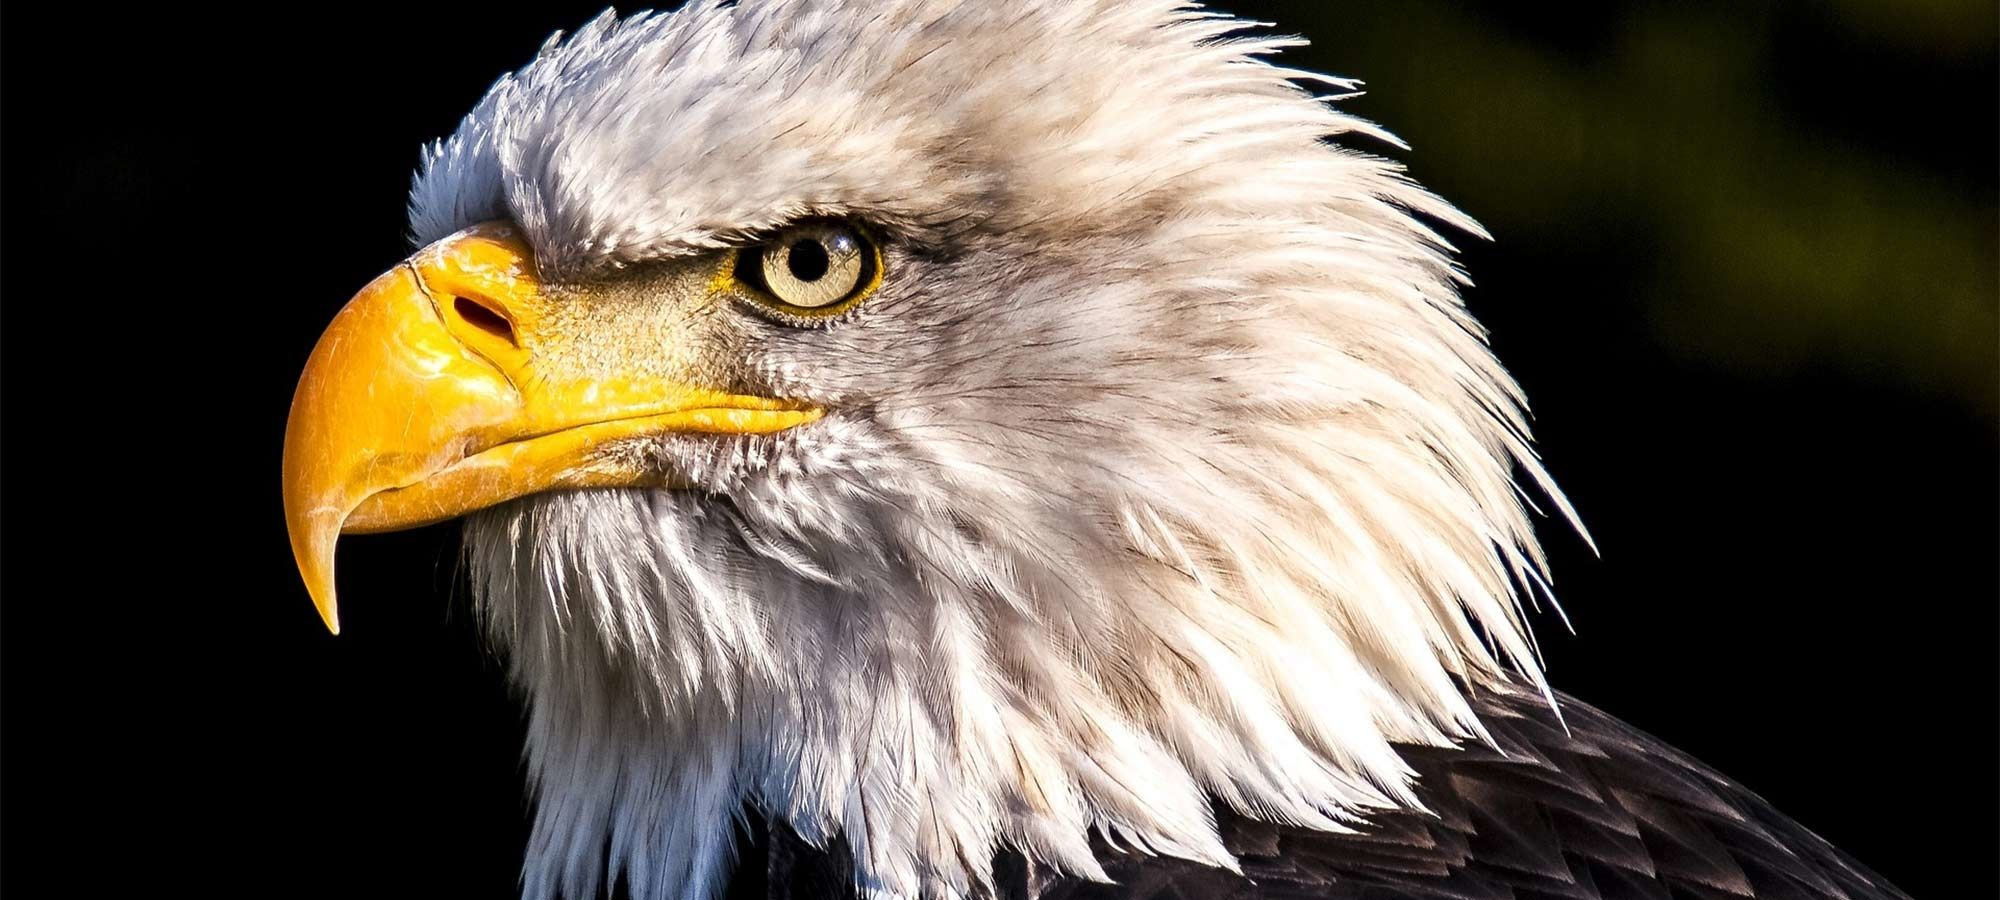

bald_eagle


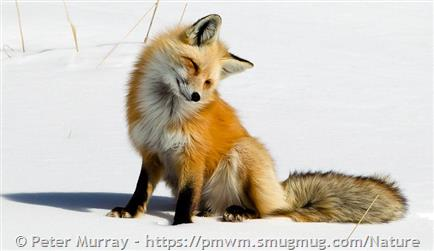

red_fox


In [25]:
# You need to download the prepared data and unzip the file in current path('./')
# oregon_wildlife/bald_eagle
# oregon_wildlife/black_bear
# oregon_wildlife/cougar
# oregon_wildlife/deer
# oregon_wildlife/nutria
# oregon_wildlife/raccoon
# oregon_wildlife/raven
# oregon_wildlife/red_fox
# oregon_wildlife/sea_lions
# oregon_wildlife/virginia_opossum
data_root = pathlib.Path('./oregon_wildlife')

# print the subfolders.
print('classes:')
for item in data_root.iterdir():
    print(item)
    
all_image_paths = list(data_root.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths]
all_image_paths = shuffle(all_image_paths, random_state=1)
all_image_paths = [path for path in all_image_paths if path[-3:] not in ('gif','bmp')]
image_count = len(all_image_paths)
print('\ntotal img num:', image_count)

# random showing 3 iamges for you
for n in range(3):
    image_path = random.choice(all_image_paths)
    display(Image(filename=image_path, width=200, height=200))
    print(image_path.split('/')[-2])

In [26]:
# get the label
label_names = sorted(item.name for item in data_root.glob('*/') if item.is_dir())
# total label
n_classes = len(label_names)
print("\nlabel_names:")
print(label_names)

# get the mapping dict
label_to_index = dict((name, index) for index,name in enumerate(label_names))
index_to_label = dict((index, name) for index,name in enumerate(label_names))
print("\nlabel_to_index:")
print(label_to_index)

# get the label data
all_image_label = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths]
print("First 10 label indices: ", all_image_label[:10])


label_names:
['bald_eagle', 'black_bear', 'cougar', 'deer', 'nutria', 'raccoon', 'raven', 'red_fox', 'sea_lions', 'virginia_opossum']

label_to_index:
{'bald_eagle': 0, 'black_bear': 1, 'cougar': 2, 'deer': 3, 'nutria': 4, 'raccoon': 5, 'raven': 6, 'red_fox': 7, 'sea_lions': 8, 'virginia_opossum': 9}
First 10 label indices:  [6, 3, 8, 5, 5, 0, 2, 1, 1, 7]


In [28]:
# Create training and testing sets using an 80-20 split
img_path_train, img_path_test, label_train, label_test = train_test_split(all_image_paths,
                                all_image_label,test_size=0.2,random_state=0)
print('training data: %d'%(len(img_path_train)))
print('testing data: %d'%(len(img_path_test)))

# save (img_path, label) pairs
with open('train.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['img_path', 'label'])
    for img_path, label in zip(img_path_train, label_train):
        writer.writerow([img_path, label])
        
with open('test.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['img_path', 'label'])
    for img_path, label in zip(img_path_test, label_test):
        writer.writerow([img_path, label])

training data: 5734
testing data: 1434


## Create Data Loader

In [29]:
# Feel free to change IMAGE_SIZE_CROPPED if using random_crop in your data augmentation process, but make sure the input resize back to (300,300,3) before feed into VGG16
IMAGE_SIZE_CROPPED = 224
IMAGE_HEIGHT = 300
IMAGE_WIDTH = 300
IMAGE_DEPTH = 3

In [30]:
# construct a new dataset with time informantion
class TimeMeasuredDataset(tf.data.Dataset):
    # OUTPUT: (steps, timings, counters, img, label)
    OUTPUT_SIGNATURE=(
        tf.TensorSpec(shape=(2, 1), dtype=tf.string), # steps: [("Open",), ("Read",)]
        tf.TensorSpec(shape=(2, 2), dtype=tf.float32), # timings: [(open_enter, open_elapsed), (read_enter, read_elapsed)]
        tf.TensorSpec(shape=(2, 3), dtype=tf.int32), # counters: [(instance_idx, epoch_idx, -1), (instance_idx, epoch_idx, example_idx)]
        tf.TensorSpec(shape=(300,300,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32) # label
    )

    _INSTANCES_COUNTER = itertools.count()  # Number of datasets generated
    _EPOCHS_COUNTER = defaultdict(itertools.count)  # Number of epochs done for each dataset

    def _generator(instance_idx, filename, open_file, read_file):
        epoch_idx = next(TimeMeasuredDataset._EPOCHS_COUNTER[instance_idx])

        # Opening the file
        open_enter = time.perf_counter()
        img_paths, label = open_file(filename)
        open_elapsed = time.perf_counter() - open_enter
        # ----------------
        
        # Reading the file        
        for sample_idx in range(len(img_paths)):
            # Reading data (line, record) from the file
            read_enter = time.perf_counter()
            img = read_file(img_paths[sample_idx])
            read_elapsed = time.perf_counter() - read_enter

            yield (
                [("Open",), ("Read",)],
                [(open_enter, open_elapsed), (read_enter, read_elapsed)],
                [(instance_idx, epoch_idx, -1), (instance_idx, epoch_idx, sample_idx)],
                img,
                label[sample_idx]
            )
            open_enter, open_elapsed = -1., -1.  # Negative values will be filtered


    def __new__(cls, filename, open_file, read_file):
        def generator_func(instance_idx, filename):
            return cls._generator(instance_idx, filename, open_file, read_file)

        return tf.data.Dataset.from_generator(
            generator_func,
            output_signature=cls.OUTPUT_SIGNATURE,
            args=(next(cls._INSTANCES_COUNTER), filename)
        )

In [31]:
def open_file(filename):
    rows = pd.read_csv(filename.decode("utf-8"))
    img_paths = rows['img_path'].tolist()
    label = rows['label'].tolist()
    return img_paths, label

def read_file(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=IMAGE_DEPTH)
    img = tf.image.resize(img, (IMAGE_HEIGHT, IMAGE_WIDTH))
    img = tf.cast(img, tf.float32)
    img = tf.divide(img,255.0)
    return img

def dataset_generator_fun_train(*args):
    return TimeMeasuredDataset('train.csv', open_file, read_file)

def dataset_generator_fun_test(*args):
    return TimeMeasuredDataset('test.csv', open_file, read_file)

In [32]:
# feel free to modify these two Settings.
BUFFER_SIZE = 8000 # 10000
BATCH_SIZE = 64  # change to 64

## batch : how many samples are processes per step
## buffer_size: when apply to shuffle how well-shuffled the dataset is (一次裝多少個)

dataset_train = tf.data.Dataset.range(1).flat_map(dataset_generator_fun_train).batch(BATCH_SIZE, drop_remainder=True)
dataset_test = tf.data.Dataset.range(1).flat_map(dataset_generator_fun_test).batch(BATCH_SIZE, drop_remainder=True)

tf.Tensor(
[[b'Open']
 [b'Read']], shape=(2, 1), dtype=string) tf.Tensor(
[[4.4026931e+05 2.5261850e-03]
 [4.4026931e+05 1.2611568e-02]], shape=(2, 2), dtype=float32) tf.Tensor(
[[ 0  0 -1]
 [ 0  0  0]], shape=(2, 3), dtype=int32)
(300, 300, 3)


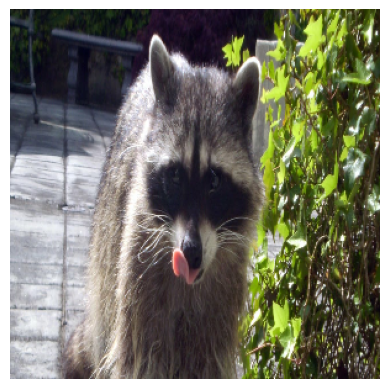

raccoon


In [33]:
for steps, timings, counters, img, label in dataset_train.take(1):
    print(steps[0], timings[0], counters[0])
    print(img[0].shape)
    plt.imshow(img[0]) 
    plt.axis('off') 
    plt.show()
    print(index_to_label[label[0].numpy()])

## Build CNN Model

In [34]:
base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3),
    pooling=None,
)
for layer in base_model.layers:
    layer.trainable = False

top_model = models.Sequential()
top_model.add(layers.Flatten())
top_model.add(layers.Dense(4096, activation='relu'))
top_model.add(layers.Dropout(0.5))
top_model.add(layers.Dense(1024, activation='relu'))
top_model.add(layers.Dropout(0.5))
top_model.add(layers.Dense(n_classes, activation='softmax'))

wild_model = tf.keras.Model(inputs=base_model.input, outputs=top_model(base_model.output)) 

## check summary
wild_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 300, 300, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 300, 300, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 150, 150, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 150, 150, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 75, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 75, 75, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 75, 75, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 75, 75, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 37, 37, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 37, 37, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 37, 37, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 37, 37, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 18, 18, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 10)             │   174,078,986 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,793,674 (720.19 MB)

 Trainable params: 174,078,986 (664.06 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [35]:
# save the initialization of weights 
# in newer TensorFlow versions (≥ 2.15 / Keras 3),
# model.save_weights() enforces a stricter filename convention.
wild_model.save_weights("wild_model.weights.h5")

In [36]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

In [37]:
@tf.function
def train_step(image, label):
    with tf.GradientTape() as tape:
        predictions = wild_model(image, training=True)
        loss = loss_object(label, predictions)
    gradients = tape.gradient(loss, wild_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, wild_model.trainable_variables))

    train_loss(loss)
    train_accuracy(label, predictions)
    
@tf.function
def test_step(image, label):
    predictions = wild_model(image, training=False)
    loss = loss_object(label, predictions)

    test_loss(loss)
    test_accuracy(label, predictions)

In [38]:
def timelined_benchmark(dataset_train, dataset_test, EPOCHS):
    steps_acc = tf.zeros([0, 1], dtype=tf.dtypes.string)
    times_acc = tf.zeros([0, 2], dtype=tf.dtypes.float32)
    values_acc = tf.zeros([0, 3], dtype=tf.dtypes.int32)

    start_time = time.perf_counter()
    print("start time: ", start_time)
    for epoch in range(EPOCHS):
        epoch_enter = time.perf_counter()

        # Reset the metrics at the start of the next epoch
        train_loss.reset_state() # syntax change for tf 2.x
        train_accuracy.reset_state()
        test_loss.reset_state()
        test_accuracy.reset_state()

        tf.print("training:")
        for steps, times, values, image, label in tqdm(dataset_train, total=math.floor(len(img_path_train)/BATCH_SIZE)):
            time.sleep(0.05)
            
            steps_acc = tf.concat([steps_acc, tf.reshape(steps, (steps.shape[0]*steps.shape[1], 1))], axis=0)
            times_acc = tf.concat([times_acc, tf.reshape(times, (times.shape[0]*times.shape[1], 2))], axis=0)
            values_acc = tf.concat([values_acc, tf.reshape(values, (values.shape[0]*values.shape[1], 3))], axis=0)

            # record training time
            train_enter = time.perf_counter()
            train_step(image, label)
            train_elapsed = time.perf_counter() - train_enter
            
            time.sleep(0.05)
            
            train_time = tf.concat([tf.fill([times.shape[0], 1], train_enter), tf.fill([times.shape[0], 1], train_elapsed)], axis=1) # shape=(times.shape[0], 2)
            steps_acc = tf.concat([steps_acc, tf.fill([steps.shape[0], 1], "Train")], axis=0)
            times_acc = tf.concat([times_acc, train_time], axis=0)
            values_acc = tf.concat([values_acc, values[:,-1,:]], axis=0)

        tf.print("testing:")
        for steps, times, values, image, label in tqdm(dataset_test, total=math.floor(len(img_path_test)/BATCH_SIZE)):
            time.sleep(0.05)
            
            steps_acc = tf.concat([steps_acc, tf.reshape(steps, (steps.shape[0]*steps.shape[1], 1))], axis=0)
            times_acc = tf.concat([times_acc, tf.reshape(times, (times.shape[0]*times.shape[1], 2))], axis=0)
            values_acc = tf.concat([values_acc, tf.reshape(values, (values.shape[0]*values.shape[1], 3))], axis=0)

            test_enter = time.perf_counter()
            test_step(image, label)
            test_elapsed = time.perf_counter() - test_enter
            
            time.sleep(0.05)
            
            test_time = tf.concat([tf.fill([times.shape[0], 1], test_enter), tf.fill([times.shape[0], 1], test_elapsed)], axis=1) # shape=(times.shape[0], 2)
            steps_acc = tf.concat([steps_acc, tf.fill([steps.shape[0], 1], "Test")], axis=0)
            times_acc = tf.concat([times_acc, test_time], axis=0)
            values_acc = tf.concat([values_acc, values[:,-1,:]], axis=0)
            
        template = 'Epoch {:0}, Loss: {:.4f}, Accuracy: {:.4f}, test Loss: {:.4f}, test Accuracy: {:.4f}'
        tf.print (template.format(epoch+1,
                               train_loss.result(),
                               train_accuracy.result()*100,
                               test_loss.result(),
                               test_accuracy.result()*100))

        epoch_elapsed = time.perf_counter() - epoch_enter
        steps_acc = tf.concat([steps_acc, [["Epoch"]]], axis=0)
        times_acc = tf.concat([times_acc, [(epoch_enter, epoch_elapsed)]], axis=0)
        values_acc = tf.concat([values_acc, [[-1, epoch, -1]]], axis=0)

    tf.print("Execution time:", time.perf_counter() - start_time)
    return {"steps": steps_acc, "times": times_acc, "values": values_acc}

# Results
## 1 Run Naive : without data transformation and pipeline optimization

The accuracy now is 80.97% in testing set, costing with 143.2 sec. Now try some data augmentation (transformation) to observe whether the accuracy and execution time are increased or decreased.

start time:  435316.793823918
training:


100%|██████████| 89/89 [00:40<00:00,  2.21it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.35it/s]

Epoch 1, Loss: 4.8801, Accuracy: 23.6482, test Loss: 1.4340, test Accuracy: 55.7528
training:


...

Epoch 2, Loss: 1.2242, Accuracy: 57.1102, test Loss: 0.7097, test Accuracy: 80.6108
training:



100%|██████████| 89/89 [00:37<00:00,  2.37it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.37it/s]

Epoch 3, Loss: 0.8768, Accuracy: 69.5049, test Loss: 0.6090, test Accuracy: 80.9659
Execution time: 143.24012975103687


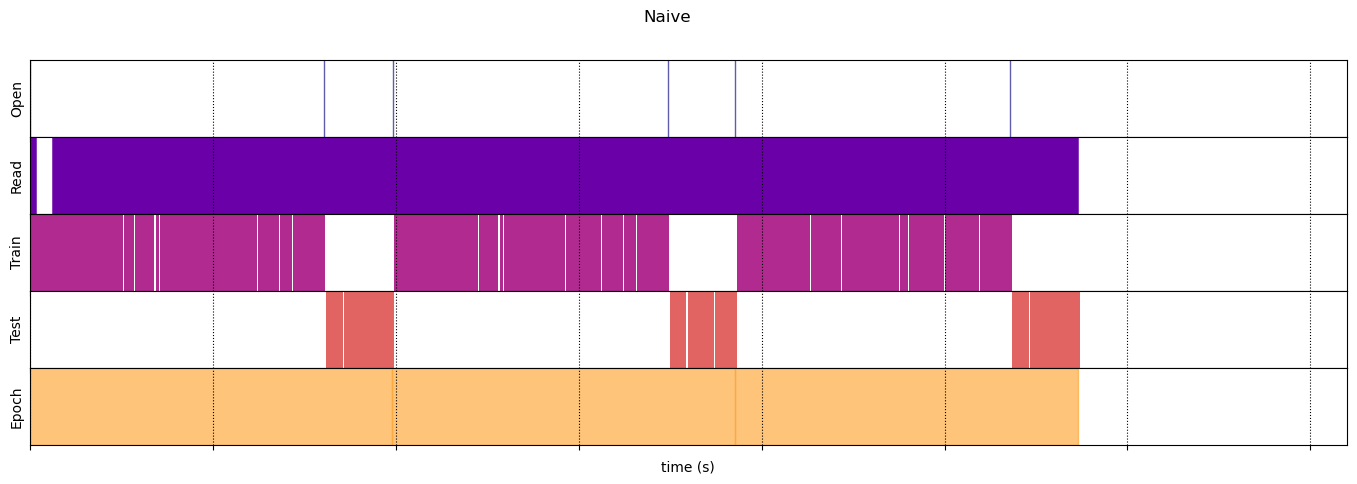

In [18]:
timeline_Naive = timelined_benchmark(dataset_train, dataset_test, EPOCHS=3)

draw_timeline(timeline=timeline_Naive, title="Naive", min_width=180) # 3000 change to 180 to be closer

## 2. Augmenatation
### 2-1 Augementation: input transfromation mentioned above (e.g. shuffle, batch, repeat, map(random_crop, random_flip_left_right, ...)) but without optimization terms

In [39]:
## TODO: build `dataset_train_augmentation` and `dataset_test_augmentation` with transformation
## Remember to define your own map functions with map_decorator before calling map
# dataset_train_augmentation = tf.data.Dataset.range(1). ...
# dataset_test_augmentation = tf.data.Dataset.range(1). ...


def map_decorator(func):
    def wrapper(steps, times, values, image, label):
        # Use a tf.py_function to prevent auto-graph from compiling the method
        return tf.py_function(
            func,
            inp=(steps, times, values, image, label),
            Tout=(steps.dtype, times.dtype, values.dtype, image.dtype, tf.int32)
        )
    return wrapper

@map_decorator
def map_fun_with_time(steps, times, values, image, label):
    # time.sleep(0.1)
    
    # record the enter time into map_fun()
    map_enter = time.perf_counter()
    
    # distorted_image = tf.image.random_crop(image, [IMAGE_SIZE_CROPPED,IMAGE_SIZE_CROPPED,IMAGE_DEPTH])
    # distorted_image = tf.image.resize(distorted_image, [IMAGE_HEIGHT, IMAGE_WIDTH])
    distorted_image = tf.image.random_flip_left_right(image) #
    distorted_image = tf.image.random_brightness(distorted_image, max_delta=63)
    distorted_image = tf.image.random_contrast(distorted_image, lower=0.2, upper=1.8)
    distorted_image = tf.image.per_image_standardization(distorted_image)
    
    map_elapsed = time.perf_counter() - map_enter
    # ----------------
    
    return tf.concat((steps, [["Map"]]), axis=0),\
           tf.concat((times, [[map_enter, map_elapsed]]), axis=0),\
           tf.concat((values, [values[-1]]), axis=0),\
           distorted_image,\
           label

@map_decorator
def map_fun_test_with_time(steps, times, values, image, label):
    # time.sleep(0.1)
    
    # record the enter time into map_fun_test()
    map_enter = time.perf_counter()
    
    distorted_image = tf.image.resize(image, [IMAGE_HEIGHT, IMAGE_WIDTH])
    distorted_image = tf.image.per_image_standardization(distorted_image)
    
    map_elapsed = time.perf_counter() - map_enter
    # ----------------
    
    return tf.concat((steps, [["Map"]]), axis=0),\
           tf.concat((times, [[map_enter, map_elapsed]]), axis=0),\
           tf.concat((values, [values[-1]]), axis=0),\
           distorted_image,\
           label


dataset_train_augmentation = tf.data.Dataset.range(1).flat_map(dataset_generator_fun_train)\
                                                     .map(map_fun_with_time)\
                                                     .shuffle(100) \
                                                     .batch(BATCH_SIZE, drop_remainder=True)
dataset_test_augmentation = tf.data.Dataset.range(1).flat_map(dataset_generator_fun_test)\
                                                    .map(map_fun_test_with_time)\
                                                    .batch(BATCH_SIZE, drop_remainder=True)
# no shffule for test as The evaluation must be deterministic and repeatable

In [22]:
# load the same initialization of weights and re-train with optimized input pipeline
wild_model.load_weights('wild_model.weights.h5')
timeline_Augmentation = timelined_benchmark(dataset_train_augmentation, dataset_test_augmentation, EPOCHS=3)

start time:  437364.525039002
training:


100%|██████████| 89/89 [00:46<00:00,  1.91it/s]

testing:



100%|██████████| 22/22 [00:13<00:00,  1.64it/s]

Epoch 1, Loss: 1.6325, Accuracy: 58.0934, test Loss: 0.3769, test Accuracy: 88.1392
training:


...

Epoch 2, Loss: 0.4916, Accuracy: 83.7781, test Loss: 0.2299, test Accuracy: 92.8267
training:



100%|██████████| 89/89 [00:45<00:00,  1.94it/s]

testing:



100%|██████████| 22/22 [00:10<00:00,  2.01it/s]

Epoch 3, Loss: 0.3857, Accuracy: 87.4298, test Loss: 0.2181, test Accuracy: 92.5426
Execution time: 175.59130540199112


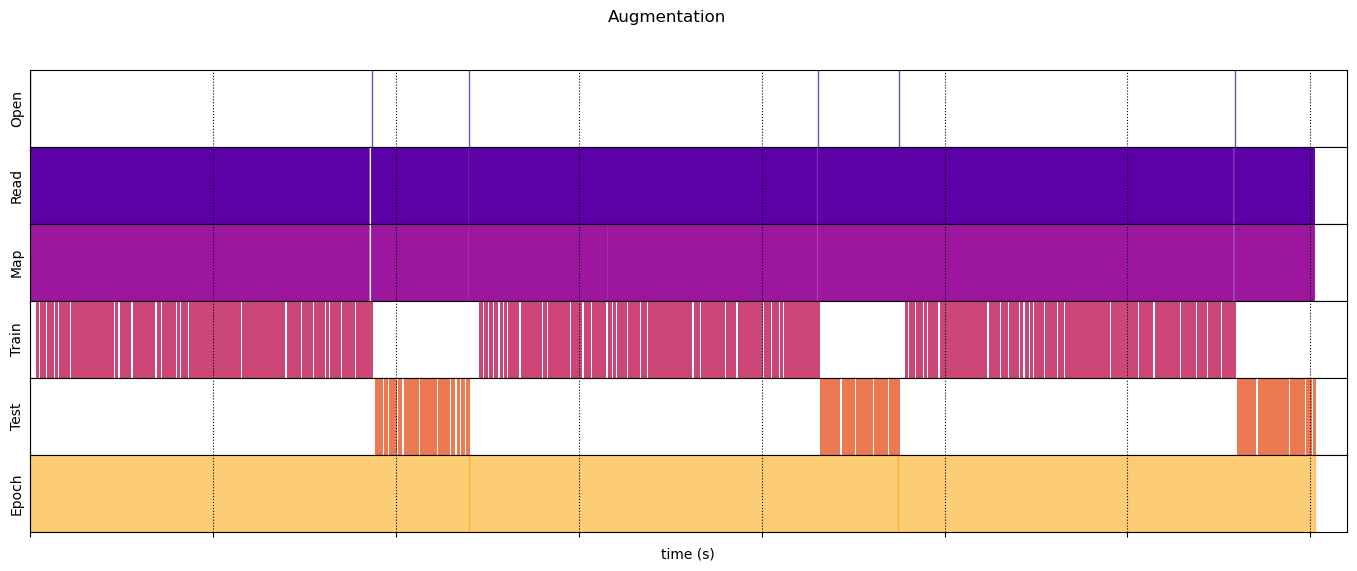

In [25]:
draw_timeline(timeline=timeline_Augmentation, title="Augmentation", min_width=180) # 3000 change to 180 to be closer

### 2-2 Compare the performance and time consumption to the Naive one.

* Augmentation methods during training:  
1. flat map: to flatten datasets. 
2. map: randomly apply (flip + brightness change + contrast change) and then final standardize for the input  
3. shuffle (100) : randomly mixes the order of samples, to prevent model seeing images in the same order every epoch! It can improve robustness while keeping memory usage moderate (with small buffer size 100)
4. batch (BATCH_SIZE = 64) : Groups 64 augmented samples into a batch for each gradient update. This improves GPU/TPU efficiency and stabilizes gradient estimation.  

* Result: 
    * Accuracy increase from 80.97% to 92.54% in testing set (improve 14.29%)
    * Time cost (augment without optimization) increase from 143.24s to 175.59s (degrade 18.01%) 

With above augementation, it increase accuracy but also increase the timing cost.  
    

## 3 Re-train your model with optimized terms, comparing the performance and time consumption
After trying data augmentation (transformation), it's time to optimize what you did above for better efficiency.

he optimization is including:

1. [prefetching](https://www.tensorflow.org/guide/data_performance#prefetching): overlaps the preprocessing and model execution of a training step.
2. [Interleave (Parallelizing data extraction)](https://www.tensorflow.org/guide/data_performance#parallelizing_data_extraction): parallelize the data loading step, interleaving the contents of other datasets (such as data file readers).
3. [Parallel mapping](https://www.tensorflow.org/guide/data_performance#parallelizing_data_transformation): parallelized mapping across multiple CPU cores.
4. [Caching](https://www.tensorflow.org/guide/data_performance#caching): cache a dataset, save some operations (like file opening and data reading) from being executed during each epoch.
5. [Vectorizing mapping](https://www.tensorflow.org/guide/data_performance#vectorizing_mapping): batch before map, so that mapping can be vectorized.

### 3-1 Optimization A.

1. Add ```.interleave()``` for parallel reads to improve I/O
2. Add ```.map(num_parallel_calls=AUTO)``` to enable multiple threads to process mapping transformation(time for augmenation process)
3. Add ```prefetch``` to let next batch prepared during training (like a pipeline), to eliminate the gpu idle time

* training optimized process : interleave -> map -> shuffle -> batch -> prefetch
* epoch = 3


In [ ]:
## TODO: build `dataset_train_optimized` and `dataset_test_optimized` with transformation and optimzation
## Remember to re-define your own map functions again to make mapping time re-calculated

# dataset_train_optimized = tf.data.Dataset.range(1). ...
# dataset_test_optimized = tf.data.Dataset.range(1). ...
dataset_train_optimized = (
    tf.data.Dataset.range(1)
    .interleave(dataset_generator_fun_train, num_parallel_calls=tf.data.AUTOTUNE)   # 1. generate samples
    # .cache()                                                                      # 2. cache decoded samples in memory
    .map(map_fun_with_time, num_parallel_calls=tf.data.AUTOTUNE)    # 3. parallel mapping (per sample)
    .shuffle(100)                                                   # 4. shuffle samples
    .batch(BATCH_SIZE, drop_remainder=True)                         # 5. batch afterwards
    .prefetch(tf.data.AUTOTUNE)                                     # 6. prefetch next batch while training
)

dataset_test_optimized = (
    tf.data.Dataset.range(1)
    .interleave(dataset_generator_fun_test, num_parallel_calls=tf.data.AUTOTUNE)
    # .cache()
    .map(map_fun_test_with_time, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

start time:  443990.569995221
training:


100%|██████████| 89/89 [00:38<00:00,  2.30it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.35it/s]

Epoch 1, Loss: 6.0469, Accuracy: 45.1194, test Loss: 0.5648, test Accuracy: 85.5824
training:


...

Epoch 2, Loss: 0.6422, Accuracy: 78.3006, test Loss: 0.3119, test Accuracy: 91.9034
training:



100%|██████████| 89/89 [00:39<00:00,  2.27it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.34it/s]

Epoch 3, Loss: 0.4335, Accuracy: 85.4108, test Loss: 0.2450, test Accuracy: 92.9688
Execution time: 144.9728122210363


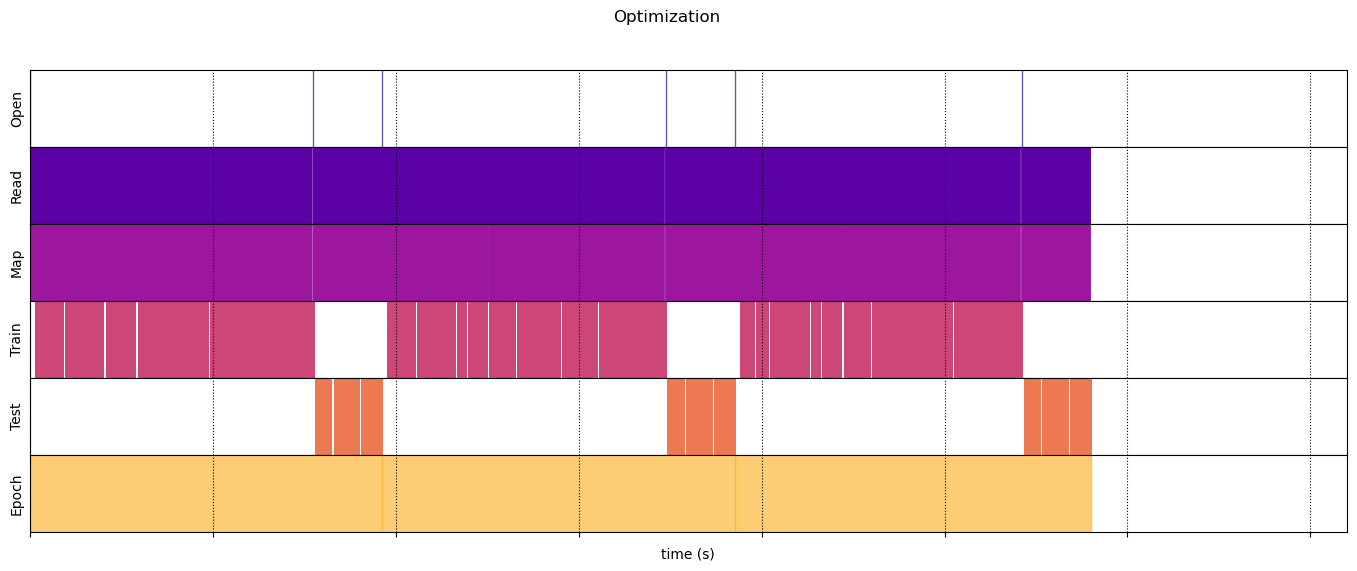

In [51]:
# load the same initialization of weights and re-train with optimized input pipeline
wild_model.load_weights('wild_model.weights.h5')
timeline_Optimization = timelined_benchmark(dataset_train_optimized, dataset_test_optimized, EPOCHS=3)

draw_timeline(timeline=timeline_Optimization, title="Optimization", min_width=180) # 3000 change to 180 to be closer

### 3-2 Optimization B.

All the same with the 3-1 Optimization A. but use more epoch (from 3 to 6), to see if it increase accuracy
* epoch = 6

It does improve the accuracy from 92% to 97%

In [77]:
# load the same initialization of weights and re-train with optimized input pipeline
timeline_Optimization_moreE = timelined_benchmark(dataset_train_optimized, dataset_test_optimized, EPOCHS=6)


start time:  448323.586426277
training:


100%|██████████| 89/89 [00:49<00:00,  1.79it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.40it/s]

Epoch 1, Loss: 0.0932, Accuracy: 97.4719, test Loss: 0.1205, test Accuracy: 97.0170
training:


...

Epoch 5, Loss: 0.1054, Accuracy: 97.1208, test Loss: 0.1084, test Accuracy: 97.1591
training:



100%|██████████| 89/89 [00:39<00:00,  2.24it/s]

testing:



100%|██████████| 22/22 [00:15<00:00,  1.46it/s]

Epoch 6, Loss: 0.0958, Accuracy: 97.4192, test Loss: 0.0825, test Accuracy: 97.9403
Execution time: 302.98877015401376


### 3-3 Optimization C. 
* (v.s Optimization A)
* epoch both are the same = 3

Change the augmenatation process and mapping device: 
* Optimization A: interleave -> [ map -> shuffle -> batch ]-> prefetch && use CPU for mapping
* Optimization B: interleave -> [ shuffle -> batch -> map ]-> prefetch && use GPU for mapping

* Accuracy improve from: 92.54%(Optimization A) to 95.74%(Optimization C)

* Reason: Changing the order of .map() relative to .shuffle() and .batch() doesn’t just affect speed — it changes the statistical distribution of your augmented data! 
    * If map() runs before shuffle:   
    So each image is augmented first, then all augmented samples are mixed together.  
    Every epoch, each original image is deterministically augmented once, then fed into training.  
    Effect:  
    → Low randomness per epoch.  
    → Model sees fewer variations per sample.  
    → Augmentations don’t change much across epochs unless you re-create the dataset.
    * If map() runs after shuffle and batch:  
    Raw images are shuffled first, then batched, then each batch is augmented together.  
    Each epoch, every image gets a new random augmentation (flip, brightness, contrast, etc.).  
    The order of samples and their augmentations are both randomized.  
    Effect:  
    → Much stronger stochasticity (more data variety).  
    → Model sees different perturbations every epoch → better generalization.  
    → Higher accuracy 

In [70]:

def map_fun_with_time_gpu(steps, times, values, image, label):
    map_enter = time.perf_counter()
    # map_enter = tf.timestamp()
    distorted_image = tf.image.random_flip_left_right(image) #
    distorted_image = tf.image.random_brightness(distorted_image, max_delta=63)
    distorted_image = tf.image.random_contrast(distorted_image, lower=0.2, upper=1.8)
    distorted_image = tf.image.per_image_standardization(distorted_image)
    
    map_elapsed = time.perf_counter() - map_enter
    # return tf.concat((steps, [["Map"]]), axis=0),\
    #        tf.concat((times, [[map_enter, map_elapsed]]), axis=0),\
    #        tf.concat((values, [values[-1]]), axis=0),\
    #        distorted_image,\
    #        label

    # map_elapsed = tf.timestamp() - map_enter
    return (
        tf.concat((steps, tf.tile([[["Map"]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        tf.concat((times, tf.tile([[[map_enter, map_elapsed]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        tf.concat((values, tf.tile([[values[-1][0]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        distorted_image,
        label,
    )

def map_fun_test_with_time_gpu(steps, times, values, image, label):
    # # record the enter time into map_fun_test()
    map_enter = time.perf_counter()
    # map_enter = tf.timestamp()
    distorted_image = tf.image.resize(image, [IMAGE_HEIGHT, IMAGE_WIDTH])
    distorted_image = tf.image.per_image_standardization(distorted_image)
    
    map_elapsed = time.perf_counter() - map_enter
    # return tf.concat((steps, [["Map"]]), axis=0),\
    #        tf.concat((times, [[map_enter, map_elapsed]]), axis=0),\
    #        tf.concat((values, [values[-1]]), axis=0),\
    #        distorted_image,\
    #        label

    # map_elapsed = tf.timestamp() - map_enter
    return (
        tf.concat((steps, tf.tile([[["Map"]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        tf.concat((times, tf.tile([[[map_enter, map_elapsed]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        tf.concat((values, tf.tile([[values[-1][0]]], [tf.shape(distorted_image)[0], 1, 1])), axis=1),
        distorted_image,
        label,
    )
# tf.debugging.set_log_device_placement(True)
dataset_train_optimized_gpu = (
    tf.data.Dataset.range(1)
    .interleave(dataset_generator_fun_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(100)
    .batch(BATCH_SIZE, drop_remainder=True)
    .map(map_fun_with_time_gpu, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_test_optimized_gpu = (
    tf.data.Dataset.range(1)
    .interleave(dataset_generator_fun_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .map(map_fun_test_with_time_gpu, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

start time:  447566.232766464
training:


100%|██████████| 89/89 [00:38<00:00,  2.32it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.32it/s]

Epoch 1, Loss: 0.1295, Accuracy: 96.2254, test Loss: 0.1218, test Accuracy: 96.2358
training:


...

Epoch 2, Loss: 0.1228, Accuracy: 96.2605, test Loss: 0.1114, test Accuracy: 96.4489
training:



100%|██████████| 89/89 [00:38<00:00,  2.30it/s]

testing:



100%|██████████| 22/22 [00:09<00:00,  2.33it/s]

Epoch 3, Loss: 0.1158, Accuracy: 96.2079, test Loss: 0.1497, test Accuracy: 95.7386
Execution time: 143.79485317901708


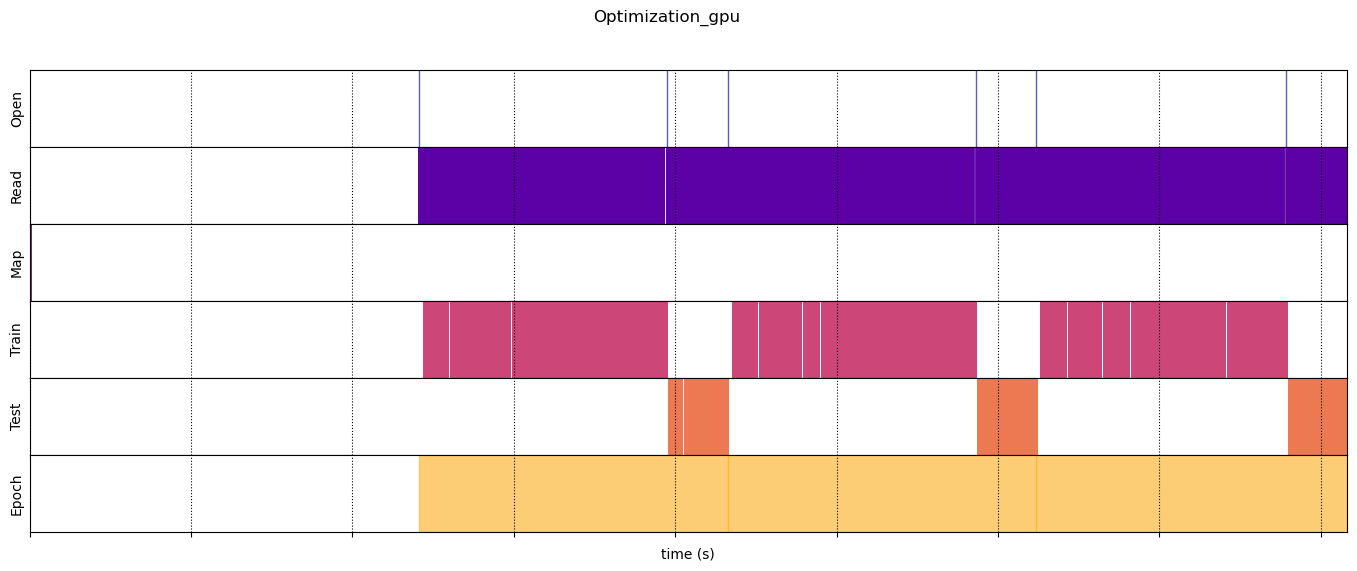

In [71]:
# load the same initialization of weights and re-train with optimized input pipeline
# wild_model.load_weights('wild_model.weights.h5')
timeline_Optimization_gpu = timelined_benchmark(dataset_train_optimized_gpu, dataset_test_optimized_gpu, EPOCHS=3)

draw_timeline(timeline=timeline_Optimization_gpu, title="Optimization_gpu", min_width=180) # 3000 change to 180 to be closer

## 4. Briefly summarize what you did and explain the performance results (accuracy and time consuming).

* It's fine if you get worse performace after applying input transfromation, or get longer time consumption after applying data pipeline optimization. Just try to analyze the result and propose your assumption, e.g.
    * Is it possible that the more difficult training data after input transfromation may need more epochs to train to get better performance?
    * Which step is the bottleneck on your device? Why? Any other steps cost more time than your expect?

### ANS:   
1. The performance improvement from augmentation but it is slower 
    * (Augmenation v.s Naive) 
    * detail description refer to 2-2
    * Accuracy increase from 80.97% to 92.54% in testing set (improve 14.29%)
    * Time cost (augment without optimization) increase from 143.24s to 175.59s (degrade 18.01%) 


2. The speed up improve after applying some optimization 
    * (Optimization A v.s Augmenation)
    * detail description refer to 3-1
    * Accuracy : 92.54%(Augmentation w/o opt) 92.97%(with opt). Not much changes for accuracy
    * Time cost decrease from 175.59s to 144.97s (improve 17.43%) 


3. Is it possible that the more difficult training data after input transfromation may need more epochs to train to get better performance? 
    * (Optimize B v.s Optimize A)
    * detail refer to 3-2
    * I change the ```epoch``` from 3 to 6, and accuracy does increase from 92.97% to 97.94%

4. **Another experimanet I tried** that changing the augmenatation process, to shuffle first then map
    * (Optimize C v.s Optimize A)
    * detail refer to 3-3
    * Accuracy improve from: 92.54%(Optimization A) to 95.74%(Optimization C), as different perturbation every epoch can improve generalization
    * The speed up not improved may be due to that using gpu for mapping will occupy the resource for training.


4. Which step is the bottleneck on your device? Why? Any other steps cost more time than your expect?
    * The ```BATCH_SIZE``` increase can improve cost of training time. As GPU can process those samples in parallel. My hardware is 22GB, the the largest possible ```BATCH_SIZE``` is 64
    * Analyzed from the graph result of 2-1 Augmentation, 'Read'(I/O) and 'Map'(augmentation process) is the bottle neck 
    -> The optimize refer to 2. (3-1)

